In [2]:
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot  as plt

In [3]:
print("=" * 60)
print("PHẦN 1: EDA")
print("=" * 60)

PHẦN 1: EDA


In [4]:
df = pd.read_csv("data/heart_disease.csv")

print(f"Dataset có {df.shape[0]} hàng và {df.shape[1]} cột")
print("Danh sách các cột:")
for col in df.columns:
    print(f"Cột: {col}")
    
print(f"\n{df.info()}")
print(f"\n{df.describe().round(2)}")
print(f"\n5 dòng đầu:\n{df.head()}")


Dataset có 2000 hàng và 12 cột
Danh sách các cột:
Cột: age
Cột: gender
Cột: bmi
Cột: blood_pressure
Cột: cholesterol
Cột: blood_sugar
Cột: smoking
Cột: family_history
Cột: physical_activity
Cột: alcohol
Cột: stress_level
Cột: heart_disease
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   gender             2000 non-null   object 
 2   bmi                1916 non-null   float64
 3   blood_pressure     2000 non-null   object 
 4   cholesterol        1903 non-null   float64
 5   blood_sugar        1888 non-null   float64
 6   smoking            2000 non-null   object 
 7   family_history     2000 non-null   int64  
 8   physical_activity  2000 non-null   object 
 9   alcohol            1060 non-null   object 
 10  stress_level       2000 non-null   int64  
 11  heart_disease      2000 

In [5]:
mapping = {0: 'Không bị bệnh', 1: 'Có bị bệnh'}
diag_list = df['heart_disease'].value_counts().rename(index = mapping)
print(f"{diag_list} - tỷ lệ: {diag_list / df['heart_disease'].count() * 100 } ")

heart_disease
Không bị bệnh    1736
Có bị bệnh        264
Name: count, dtype: int64 - tỷ lệ: heart_disease
Không bị bệnh    86.8
Có bị bệnh       13.2
Name: count, dtype: float64 


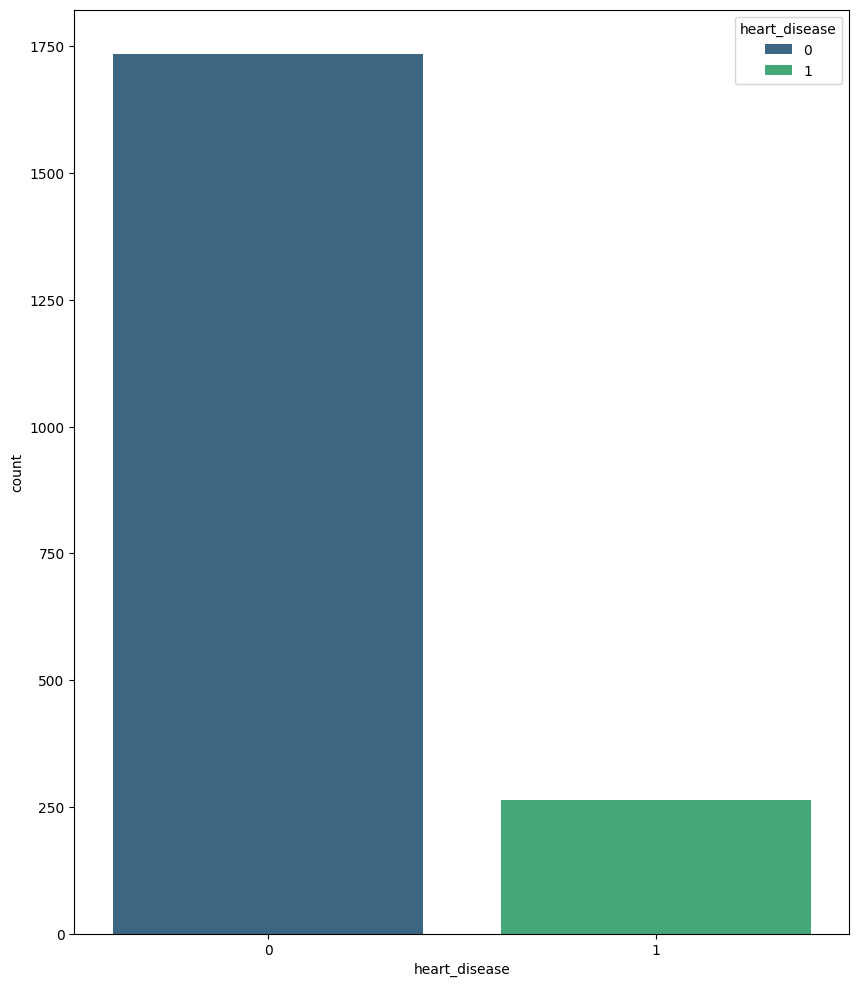

In [6]:
plt.figure(figsize = (10,12))
sns.countplot(
    data = df,
    x = 'heart_disease',
    hue='heart_disease',
    palette='viridis'
)
plt.show()

In [7]:
missing_value = df.isnull().sum()
percent = missing_value / df['gender'].count() * 100
print(f"Số lượng hàng dữ liệu bị thiếu: {missing_value} - \ntỷ lệ \n{round(percent, 2)}")
duplicated_value = df.duplicated().sum()
print(f"So hang bi trung  {duplicated_value}")

Số lượng hàng dữ liệu bị thiếu: age                    0
gender                 0
bmi                   84
blood_pressure         0
cholesterol           97
blood_sugar          112
smoking                0
family_history         0
physical_activity      0
alcohol              940
stress_level           0
heart_disease          0
dtype: int64 - 
tỷ lệ 
age                   0.00
gender                0.00
bmi                   4.20
blood_pressure        0.00
cholesterol           4.85
blood_sugar           5.60
smoking               0.00
family_history        0.00
physical_activity     0.00
alcohol              47.00
stress_level          0.00
heart_disease         0.00
dtype: float64
So hang bi trung  0


In [8]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

features_numeric = numeric_cols.drop('heart_disease')

for col in features_numeric:
    if df[col].nunique() > 10:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        
        upper = q3 + 1.5 * iqr
        lower = q1 - 1.5 * iqr
        
        outliers = (df[col] < lower) | (df[col] > upper)
        
        if outliers.any():
            print(f"Cột {col:15} | Outliers: {outliers.sum():<5} | Biên: [{lower:>6.1f}, {upper:>6.1f}]")
            df[col] = df[col].clip(lower=lower, upper=upper)

Cột bmi             | Outliers: 15    | Biên: [  10.8,   43.8]
Cột cholesterol     | Outliers: 11    | Biên: [  86.5,  314.5]
Cột blood_sugar     | Outliers: 6     | Biên: [  27.5,  183.5]


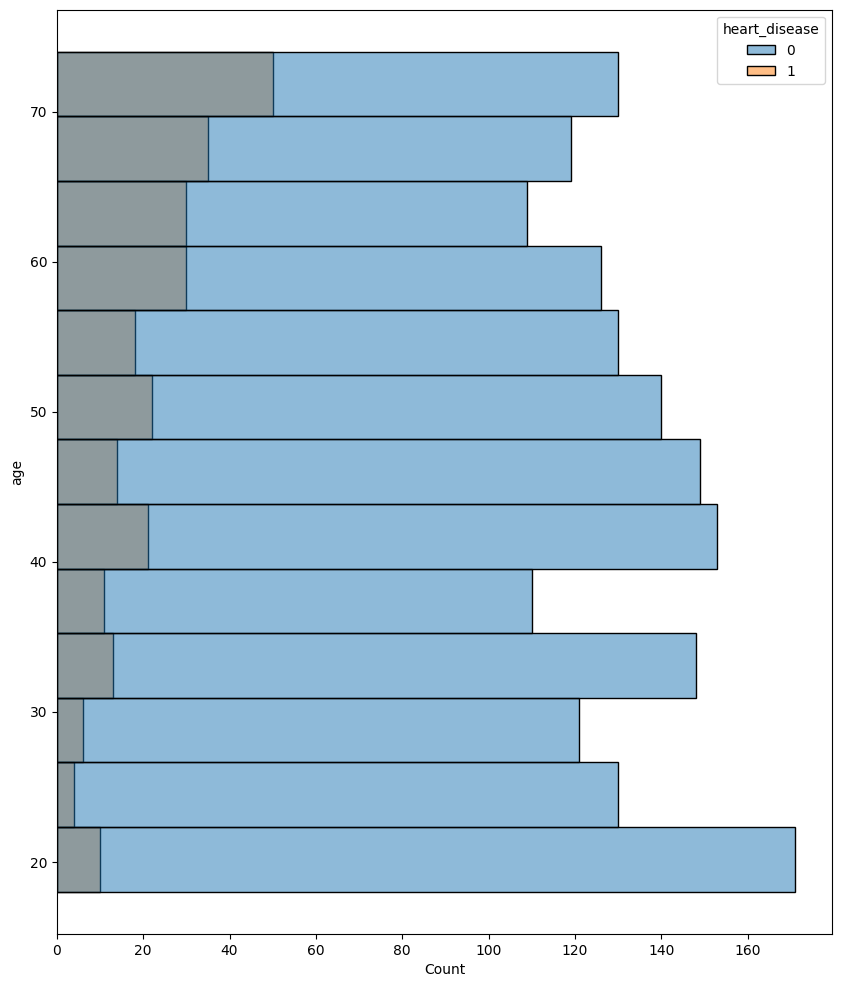

In [9]:
plt.figure(figsize = (10,12))
sns.histplot(
    data = df,
    y = 'age',
    hue = 'heart_disease'
)
plt.show()

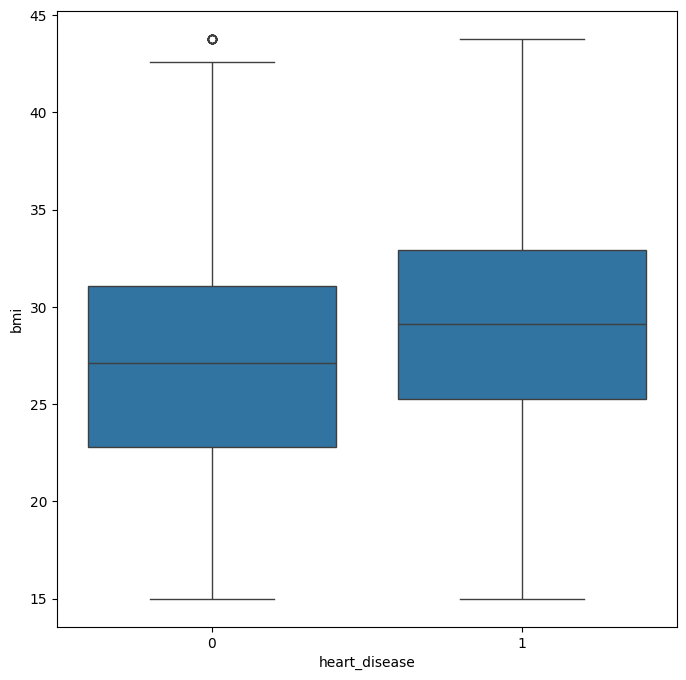

In [10]:
plt.figure(figsize=(8,8))
sns.boxplot(
    data = df,
    x = 'heart_disease',
    y = 'bmi'
)
plt.show()

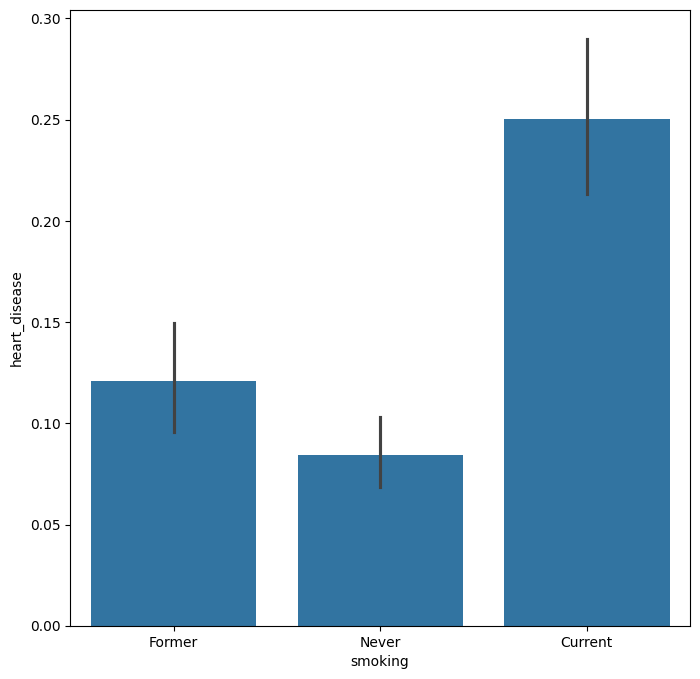

In [11]:
plt.figure(figsize=(8,8))
sns.barplot(
    data=df,
    y = 'heart_disease',
    x = 'smoking'
)
plt.show()

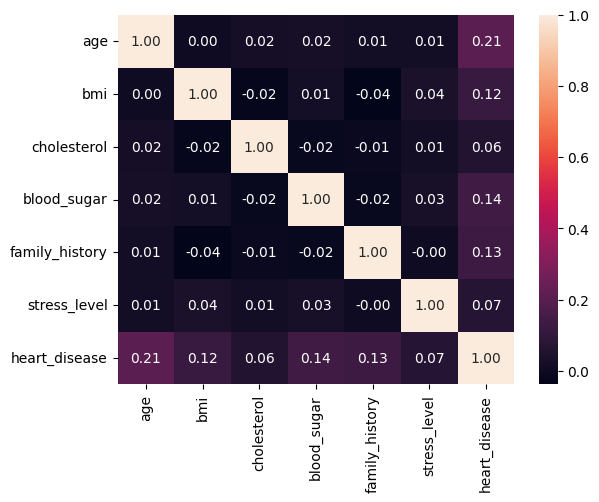

In [12]:
sns.heatmap(
    data = df.select_dtypes(include=['float64', 'int64']).corr(),
    annot=True,
    fmt=".2f"
)

plt.show()

In [13]:
print("=" * 60)
print("PHẦN 2: PREPROCESSING")
print("=" * 60)

PHẦN 2: PREPROCESSING


In [14]:
bmi_medians = df.groupby('blood_pressure')['bmi'].transform('median')

df['bmi'] = df['bmi'].fillna(bmi_medians)
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())
df['blood_sugar'] = df['blood_sugar'].fillna(df['blood_sugar'].median())
df['alcohol'] = df['alcohol'].fillna(df['alcohol'].mode()[0])

In [15]:
def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25:  return 'Normal'
    elif bmi < 30:  return 'Overweight'
    else:           return 'Obese'
    
df['bmi_category'] = df['bmi'].apply(bmi_category)

df['risk_score'] = (
    (df['blood_pressure'] == 'High').astype(int) * 2 +
    (df['smoking'] == 'Current').astype(int) * 2 +
    df['family_history'] +
    (df['physical_activity'] == 'Low').astype(int)
)

In [17]:
encode_col = ['gender', 'blood_pressure', 'smoking', 'physical_activity', 'alcohol', 'bmi_category']

df_encoded = pd.get_dummies(df, encode_col, dtype=int)

print(df_encoded.head())

   age   bmi  cholesterol  blood_sugar  family_history  stress_level  \
0   56  22.9        233.0        102.0               0             6   
1   69  27.2        233.0        173.0               0             7   
2   46  31.6        238.0         99.0               0             5   
3   32  26.2        249.0        100.0               0            10   
4   60  33.9        288.0         62.0               1             8   

   heart_disease  risk_score  gender_Female  gender_Male  ...  smoking_Never  \
0              0           0              0            1  ...              0   
1              0           0              1            0  ...              0   
2              0           0              1            0  ...              1   
3              0           2              0            1  ...              1   
4              1           4              1            0  ...              1   

   physical_activity_High  physical_activity_Low  physical_activity_Moderate  \
0     

In [20]:
print(df_encoded.shape)
print(df_encoded.isnull().sum().sum())

(2000, 25)
0


In [21]:
print("=" * 60)
print("PHẦN 3: TRAIN VÀ ĐÁNH GIÁ")
print("=" * 60)

PHẦN 3: TRAIN VÀ ĐÁNH GIÁ


In [26]:
from sklearn.model_selection import train_test_split

features_col = numeric_cols.drop('heart_disease')
X = df_encoded[features_col]
y = df_encoded['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Train: 1600 | Test: 400


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, recall_score, precision_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_A = LogisticRegression(max_iter=1000, random_state=42)
model_A.fit(X_train_scaled, y_train)

model_B = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_B.fit(X_train_scaled, y_train)

y_train_pred = model_A.predict(X_train_scaled)
y_test_pred  = model_A.predict(X_test_scaled)


acc_train =  accuracy_score(y_train, y_train_pred)
acc_test =  accuracy_score(y_test, y_test_pred)
recall_train =  recall_score(y_train, y_train_pred)
recall_test =  recall_score(y_test, y_test_pred)
precision_train =  precision_score(y_train, y_train_pred)
precision_test =  precision_score(y_test, y_test_pred)
mse_train  = mean_squared_error(y_train, y_train_pred)
mse_test   = mean_squared_error(y_test, y_test_pred)
rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)
r2_train   = r2_score(y_train, y_train_pred)
r2_test    = r2_score(y_test, y_test_pred)

print(f"\n{'Metric':<20}{'Train':>12}{'Test':>12}")
print("-" * 44)
print(f"{'Acc':<20}{acc_train:>12.0f}{acc_test:>12.0f}")
print(f"{'Acc':<20}{recall_train:>12.0f}{recall_test:>12.0f}")
print(f"{'Acc':<20}{precision_train:>12.0f}{precision_test:>12.0f}")
print(f"{'MSE':<20}{mse_train:>12.0f}{mse_test:>12.0f}")
print(f"{'RMSE':<20}{rmse_train:>12.2f}{rmse_test:>12.2f}")
print(f"{'R²':<20}{r2_train:>12.4f}{r2_test:>12.4f}")



Metric                     Train        Test
--------------------------------------------
Acc                            1           1
Acc                            0           0
Acc                            1           0
MSE                            0           0
RMSE                        0.36        0.37
R²                       -0.1192     -0.1745
